## Librerias

In [130]:
try:
    import pandas as pd
except ImportError:
    print("Pandas not installed")
    %pip install pandas --user

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Matplotlib not installed")
    %pip install matplotlib --user

import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [131]:
import pandas as pd
import matplotlib.pyplot as plt

## Lectura de datos

- [Dataset Qatar 2022: https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data](https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data)

In [132]:
archivo = "https://raw.githubusercontent.com/IgnacioPardo/Tecnologias_Exponenciales_2025/refs/heads/main/qatar.csv"

# Leer datos del archivo
mundial : pd.DataFrame = pd.read_csv(archivo)
mundial

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
0,1,Sun,20-Nov-22,17:00,Al Bayt Stadium,Daniele Orsato,Group A,QATAR,ECUADOR,67372,...,0,1,6,5,0,0,52,72,256,279
1,2,Mon,21-Nov-22,14:00,Khalifa International Stadium,Raphael Claus,Group B,ENGLAND,IRAN,45334,...,0,1,8,13,0,0,63,72,139,416
2,3,Mon,21-Nov-22,17:00,Al Thumama Stadium,Wilton Sampaio,Group A,SENEGAL,NETHERLANDS,41721,...,0,0,9,15,0,0,63,73,263,251
3,4,Mon,21-Nov-22,20:00,Ahmed bin Ali Stadium,Abdulrahman Ibrahim Al Jassim,Group B,UNITED STATES,WALES,43418,...,0,1,7,7,0,0,81,72,242,292
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,60,Sat,10-Dec-22,20:00,Al Bayt Stadium,Wilton Sampaio,Quarter-final,ENGLAND,FRANCE,68895,...,1,0,9,15,0,0,49,54,193,308
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
61,62,Wed,14-Dec-22,20:00,Al Bayt Stadium,Cesar Ramos,Semi-Final,FRANCE,MOROCCO,68294,...,0,0,13,14,0,0,72,47,328,218
62,63,Sat,17-Dec-22,16:00,Khalifa International Stadium,Abdulrahman Ibrahim Al Jassim,Play-off for third place,CROATIA,MOROCCO,44137,...,0,0,7,14,0,0,75,72,288,277


In [133]:
# Cuantos partidos se jugaron?
# Completar
len(mundial)

64

In [134]:
# Que datos tiene el dataset? (Pista: usar .info(), .describe(), .columns, .head())
# Checkear columnas
# Completar
mundial.info()
mundial.describe()
mundial.columns
mundial.head()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 59 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   match_no                         64 non-null     int64  
 1   day_of_week                      64 non-null     str    
 2   date                             64 non-null     str    
 3   hour                             64 non-null     str    
 4   venue                            64 non-null     str    
 5   referee                          64 non-null     str    
 6   group                            64 non-null     str    
 7   1                                64 non-null     str    
 8   2                                64 non-null     str    
 9   attendance                       64 non-null     int64  
 10  1_xg                             64 non-null     float64
 11  2_xg                             64 non-null     float64
 12  1_poss                           64

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
0,1,Sun,20-Nov-22,17:00,Al Bayt Stadium,Daniele Orsato,Group A,QATAR,ECUADOR,67372,...,0,1,6,5,0,0,52,72,256,279
1,2,Mon,21-Nov-22,14:00,Khalifa International Stadium,Raphael Claus,Group B,ENGLAND,IRAN,45334,...,0,1,8,13,0,0,63,72,139,416
2,3,Mon,21-Nov-22,17:00,Al Thumama Stadium,Wilton Sampaio,Group A,SENEGAL,NETHERLANDS,41721,...,0,0,9,15,0,0,63,73,263,251
3,4,Mon,21-Nov-22,20:00,Ahmed bin Ali Stadium,Abdulrahman Ibrahim Al Jassim,Group B,UNITED STATES,WALES,43418,...,0,1,7,7,0,0,81,72,242,292
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361


## Analisis

### Primera Parte

In [135]:
# Cuantas selecciones participaron?
# Completar
selecciones = pd.concat([mundial["1"], mundial["2"]]).unique()
selecciones

<StringArray>
[         'QATAR',        'ENGLAND',        'SENEGAL',  'UNITED STATES',
      'ARGENTINA',        'DENMARK',         'MEXICO',         'FRANCE',
        'MOROCCO',        'GERMANY',          'SPAIN',        'BELGIUM',
    'SWITZERLAND',        'URUGUAY',       'PORTUGAL',         'BRAZIL',
          'WALES',    'NETHERLANDS',        'TUNISIA',         'POLAND',
          'JAPAN',        'CROATIA',       'CAMEROON', 'KOREA REPUBLIC',
        'ECUADOR',           'IRAN',      'AUSTRALIA',   'SAUDI ARABIA',
         'CANADA',     'COSTA RICA',          'GHANA',         'SERBIA']
Length: 32, dtype: str

In [136]:
# Cuantas fases tiene el mundial?
fases = []
for i in range(len(mundial)):
    fase = mundial["group"][i]
    if fase.startswith("Group"):
        fase = "Group Stage"
    if fase not in fases:
        fases.append(fase)
print(fases)
print(len(fases))

['Group Stage', 'Round of 16', 'Quarter-final', 'Semi-Final', 'Play-off for third place', 'Final']
6


In [137]:
# Cual fue la "attendance" promedio por partido?
# Completar
promedio = mundial["attendance"].mean()
print(f"Attendance promedio por partido: {promedio:,.0f} personas")

Attendance promedio por partido: 53,191 personas


In [138]:
# Cual fue el partido con mas diferencia de goles?
# Completar
mundial["diferencia_goles"] = (mundial["1_goals"] - mundial["2_goals"])
Mayor_Diferencia = mundial["diferencia_goles"].max()
Partido_Mayor_Diferencia = mundial[mundial["diferencia_goles"] == Mayor_Diferencia]
Partido_Mayor_Diferencia

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied,diferencia_goles
10,11,Wed,23-Nov-22,17:00,Al Thumama Stadium,Mohammed Abdulla Hassan,Group E,SPAIN,COSTA RICA,40013,...,0,0,17,0,0,46,76,185,585,7


In [139]:
# Cual es la seleccion que mas penales metio?
penales = {}
for i in range(len(mundial)):
    e1 = mundial["1"][i]
    e2 = mundial["2"][i]
    if e1 not in penales:
        penales[e1] = 0
    if e2 not in penales:
        penales[e2] = 0
    penales[e1] = penales[e1] + mundial["1_panelties_scored"][i]
    penales[e2] = penales[e2] + mundial["2_panelties_scored"][i]

mejor = ""
mas_penales = 0
for equipo_p, cantidad in penales.items():
    if cantidad > mas_penales:
        mas_penales = cantidad
        mejor = equipo_p
print(f"{mejor}: {mas_penales} penales convertidos")

ARGENTINA: 4 penales convertidos


In [140]:
# Cual es la seleccion que mas penales le hicieron?
penales_contra = {}
for i in range(len(mundial)):
    e1 = mundial["1"][i]
    e2 = mundial["2"][i]
    if e1 not in penales_contra:
        penales_contra[e1] = 0
    if e2 not in penales_contra:
        penales_contra[e2] = 0
    penales_contra[e1] = penales_contra[e1] + mundial["2_panelties_scored"][i]
    penales_contra[e2] = penales_contra[e2] + mundial["1_panelties_scored"][i]

peor = ""
mas_en_contra = 0
for equipo_p, cantidad in penales_contra.items():
    if cantidad > mas_en_contra:
        mas_en_contra = cantidad
        peor = equipo_p
print(f"{peor}: {mas_en_contra} penales en contra")

FRANCE: 3 penales en contra


### Segunda Parte

In [141]:
equipo : str = "ARGENTINA"

In [142]:
# Seleccionar todos los partidos que jugo el equipo de "local"
# Completar

filtroLocal : pd.Series = mundial["1"] == equipo
mundial[filtroLocal]

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied,diferencia_goles
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,0,4,14,0,0,65,80,163,361,-1
23,24,Sat,26-Nov-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Group C,ARGENTINA,MEXICO,88966,...,0,4,5,0,0,63,79,220,327,2
49,50,Sat,3-Dec-22,20:00,Ahmed bin Ali Stadium,Szymon Marciniak,Round of 16,ARGENTINA,AUSTRALIA,45032,...,0,5,14,1,0,67,73,240,453,1
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,0,12,10,0,0,85,63,321,260,3
63,64,Sun,18-Dec-22,16:00,Lusail Iconic Stadium,Szymon Marciniak,Final,ARGENTINA,FRANCE,88966,...,2,11,21,0,0,87,104,280,409,0


In [143]:
# Seleccionar todos los partidos que jugo el equipo de "visitante"
# Completar

filtroVisitante : pd.Series = mundial["2"] == equipo
mundial[filtroVisitante]

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied,diferencia_goles
38,39,Wed,30-Nov-22,20:00,Lusail Iconic Stadium,Michael Oliver,Group C,POLAND,ARGENTINA,84985,...,0,25,4,0,0,67,48,438,141,-2
57,58,Fri,9-Dec-22,20:00,Lusail Iconic Stadium,Antonio Mateu Lahoz,Quarter-final,NETHERLANDS,ARGENTINA,88235,...,1,15,5,0,0,91,79,401,323,0


In [144]:
# Seleccionar todos los partidos que jugo el equipo (de "local" o "visitante")
partidos : pd.DataFrame = mundial[filtroLocal | filtroVisitante]
partidos

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied,diferencia_goles
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,0,4,14,0,0,65,80,163,361,-1
23,24,Sat,26-Nov-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Group C,ARGENTINA,MEXICO,88966,...,0,4,5,0,0,63,79,220,327,2
38,39,Wed,30-Nov-22,20:00,Lusail Iconic Stadium,Michael Oliver,Group C,POLAND,ARGENTINA,84985,...,0,25,4,0,0,67,48,438,141,-2
49,50,Sat,3-Dec-22,20:00,Ahmed bin Ali Stadium,Szymon Marciniak,Round of 16,ARGENTINA,AUSTRALIA,45032,...,0,5,14,1,0,67,73,240,453,1
57,58,Fri,9-Dec-22,20:00,Lusail Iconic Stadium,Antonio Mateu Lahoz,Quarter-final,NETHERLANDS,ARGENTINA,88235,...,1,15,5,0,0,91,79,401,323,0
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,0,12,10,0,0,85,63,321,260,3
63,64,Sun,18-Dec-22,16:00,Lusail Iconic Stadium,Szymon Marciniak,Final,ARGENTINA,FRANCE,88966,...,2,11,21,0,0,87,104,280,409,0


In [145]:
# Cuantos goles hizo el equipo en total (obtener los goles metidos de local y sumarlos con los goles metidos de visitante)
goles_local = mundial[filtroLocal]["1_goals"].sum()
goles_visitante = mundial[filtroVisitante]["2_goals"].sum()

goles : int = goles_local + goles_visitante
print(f"{equipo} hizo {goles} goles en total")

ARGENTINA hizo 15 goles en total


In [146]:
# Cuantos goles hizo el equipo en promedio
# Completar
promedio = goles / len(partidos)
print(f"{equipo} hizo {promedio:.2f} goles por partido")

ARGENTINA hizo 2.14 goles por partido


In [147]:
# Cuantos partidos gano el equipo
# Completar
victorias_local = mundial[filtroLocal & (mundial["1_goals"] > mundial["2_goals"])]
victorias_visitante = mundial[filtroVisitante & (mundial["2_goals"] > mundial["1_goals"])]

ganados : int = len(victorias_local) + len(victorias_visitante)
print(f"{equipo} ganó {ganados} partidos")

ARGENTINA ganó 4 partidos


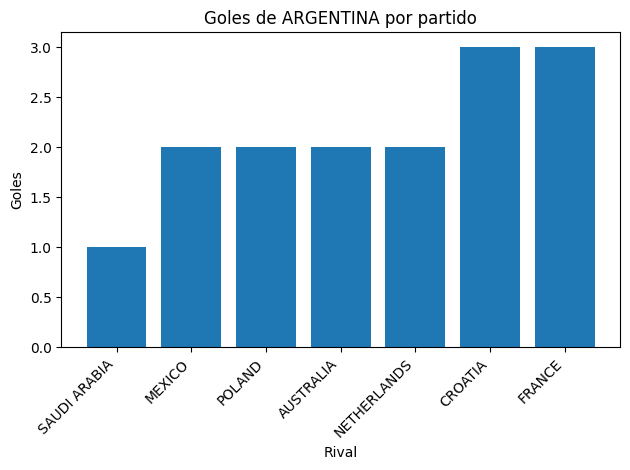

In [ ]:
# Graficar los goles hechos por el equipo en cada partido
goles_por_partido = []
rivales = []
for i in range(len(partidos)):
    if partidos["1"].iloc[i] == equipo:
        goles_por_partido.append(partidos["1_goals"].iloc[i])
        rivales.append(partidos["2"].iloc[i])
    else:
        goles_por_partido.append(partidos["2_goals"].iloc[i])
        rivales.append(partidos["1"].iloc[i])

fig, ax = plt.subplots()
ax.bar(rivales, goles_por_partido)
ax.set_title(f"Goles de {equipo} por partido")
ax.set_xlabel("Rival")
ax.set_ylabel("Goles")
plt.xticks(rotation=45, ha="right")
plt.show()

### Tercera Parte

In [149]:
# Contar cuantos goles hizo cada equipo en total en el mundial
goles_totales = {}
for i in range(len(mundial)):
    e1 = mundial["1"][i]
    e2 = mundial["2"][i]
    if e1 not in goles_totales:
        goles_totales[e1] = 0
    if e2 not in goles_totales:
        goles_totales[e2] = 0
    goles_totales[e1] = goles_totales[e1] + mundial["1_goals"][i]
    goles_totales[e2] = goles_totales[e2] + mundial["2_goals"][i]

goles_totales = pd.Series(goles_totales).sort_values(ascending=False)
goles_totales

FRANCE            16
ARGENTINA         15
ENGLAND           13
PORTUGAL          12
NETHERLANDS       10
SPAIN              9
CROATIA            8
BRAZIL             8
MOROCCO            6
GERMANY            6
SWITZERLAND        5
JAPAN              5
SENEGAL            5
KOREA REPUBLIC     5
SERBIA             5
GHANA              5
ECUADOR            4
IRAN               4
AUSTRALIA          4
CAMEROON           4
COSTA RICA         3
UNITED STATES      3
SAUDI ARABIA       3
POLAND             3
MEXICO             2
CANADA             2
URUGUAY            2
WALES              1
DENMARK            1
TUNISIA            1
QATAR              1
BELGIUM            1
dtype: int64

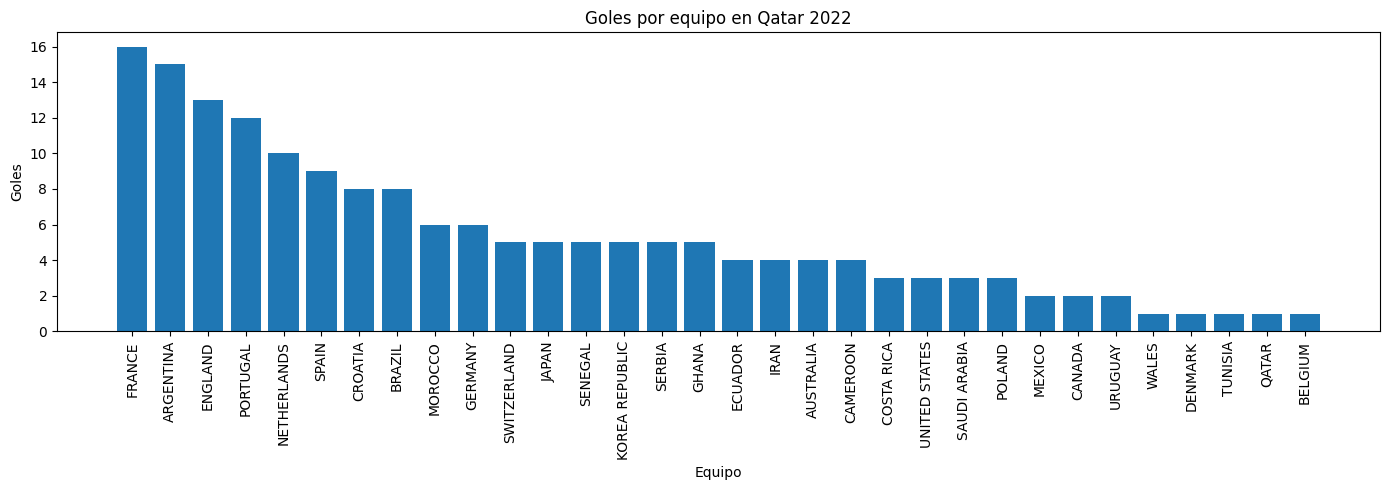

In [ ]:
# Graficar los goles por equipo en todo el mundial
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(goles_totales.index, goles_totales.values)
ax.set_title('Goles por equipo en Qatar 2022')
ax.set_xlabel('Equipo')
ax.set_ylabel('Goles')
plt.xticks(rotation=90)
plt.show()

In [151]:
# Cual es el equipo que hizo mas goles en el mundial?
# Completar
equipo_max = goles_totales.idxmax()
print(f"{equipo_max}: {int(goles_totales.max())} goles")

FRANCE: 16 goles


In [152]:
# Por cada partido, cual fue la diferencia de goles?
# Completar
mundial["diferencia_goles"] = abs(mundial["1_goals"] - mundial["2_goals"])
mundial[["1", "1_goals", "2_goals", "2", "diferencia_goles"]]

,1,1_goals,2_goals,2,diferencia_goles
0,QATAR,0,2,ECUADOR,2
1,ENGLAND,6,2,IRAN,4
2,SENEGAL,0,2,NETHERLANDS,2
3,UNITED STATES,1,1,WALES,0
4,ARGENTINA,1,2,SAUDI ARABIA,1
...,...,...,...,...,...
59,ENGLAND,1,2,FRANCE,1
60,ARGENTINA,3,0,CROATIA,3
61,FRANCE,2,0,MOROCCO,2
62,CROATIA,2,1,MOROCCO,1


In [153]:
# Por cada partido, cual fue el equipo que gano?
ganadores = []
for i in range(len(mundial)):
    if mundial["1_goals"][i] > mundial["2_goals"][i]:
        ganadores.append(mundial["1"][i])
    elif mundial["2_goals"][i] > mundial["1_goals"][i]:
        ganadores.append(mundial["2"][i])
    else:
        ganadores.append("Empate")

mundial["ganador"] = ganadores
mundial[["1", "1_goals", "2_goals", "2", "ganador"]]

,1,1_goals,2_goals,2,ganador
0,QATAR,0,2,ECUADOR,ECUADOR
1,ENGLAND,6,2,IRAN,ENGLAND
2,SENEGAL,0,2,NETHERLANDS,NETHERLANDS
3,UNITED STATES,1,1,WALES,Empate
4,ARGENTINA,1,2,SAUDI ARABIA,SAUDI ARABIA
...,...,...,...,...,...
59,ENGLAND,1,2,FRANCE,FRANCE
60,ARGENTINA,3,0,CROATIA,ARGENTINA
61,FRANCE,2,0,MOROCCO,FRANCE
62,CROATIA,2,1,MOROCCO,CROATIA


In [154]:
# En cada fase del mundial, cual fue el equipo que hizo mas goles?
orden = ["Group Stage", "Round of 16", "Quarter-final", "Semi-Final", "Play-off for third place", "Final"]

for fase in orden:
    if fase == "Group Stage":
        partidos_fase = mundial[mundial["group"].str.startswith("Group")]
    else:
        partidos_fase = mundial[mundial["group"] == fase]

    goles_por_equipo = {}
    for i in range(len(partidos_fase)):
        e1 = partidos_fase["1"].iloc[i]
        e2 = partidos_fase["2"].iloc[i]
        if e1 not in goles_por_equipo:
            goles_por_equipo[e1] = 0
        if e2 not in goles_por_equipo:
            goles_por_equipo[e2] = 0
        goles_por_equipo[e1] = goles_por_equipo[e1] + partidos_fase["1_goals"].iloc[i]
        goles_por_equipo[e2] = goles_por_equipo[e2] + partidos_fase["2_goals"].iloc[i]

    mejor_equipo = ""
    mejor_goles = 0
    for eq, g in goles_por_equipo.items():
        if g > mejor_goles:
            mejor_goles = g
            mejor_equipo = eq
    print(f"{fase}: {mejor_equipo} ({mejor_goles} goles)")

Group Stage: ENGLAND (9 goles)
Round of 16: PORTUGAL (6 goles)
Quarter-final: NETHERLANDS (2 goles)
Semi-Final: ARGENTINA (3 goles)
Play-off for third place: CROATIA (2 goles)
Final: ARGENTINA (3 goles)


### Tercera Parte

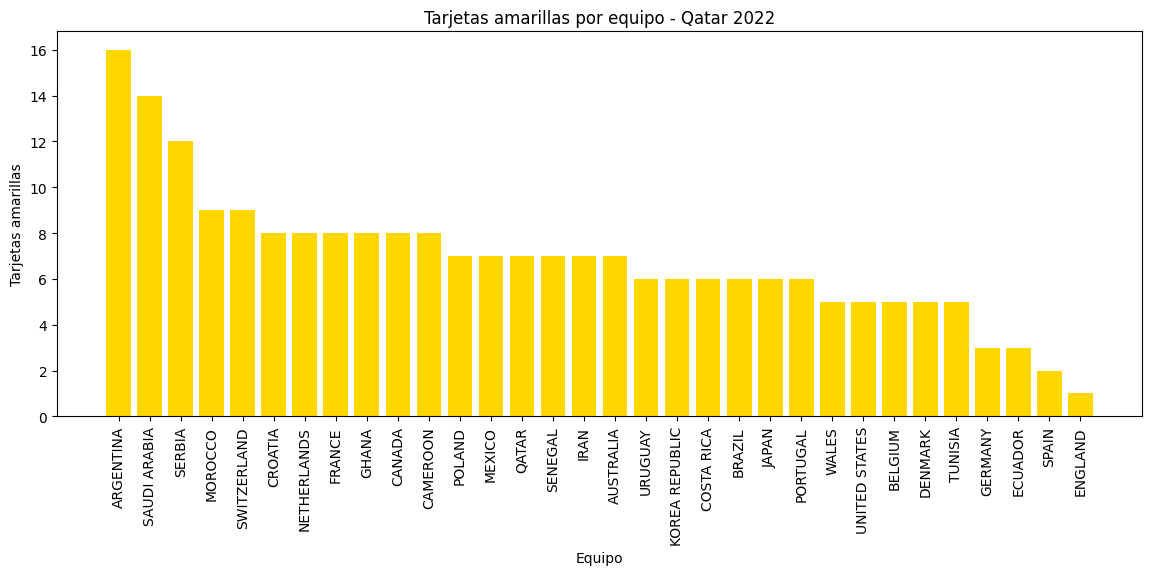

In [155]:
# Armar un grafico a partir de algun nuevo analisis que se te ocurra
# Tarjetas amarillas por equipo
amarillas = {}
for i in range(len(mundial)):
    e1 = mundial["1"][i]
    e2 = mundial["2"][i]
    if e1 not in amarillas:
        amarillas[e1] = 0
    if e2 not in amarillas:
        amarillas[e2] = 0
    amarillas[e1] = amarillas[e1] + mundial["1_yellow_cards"][i]
    amarillas[e2] = amarillas[e2] + mundial["2_yellow_cards"][i]

amarillas = pd.Series(amarillas).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(amarillas.index, amarillas.values, color="gold")
ax.set_title("Tarjetas amarillas por equipo - Qatar 2022")
ax.set_xlabel("Equipo")
ax.set_ylabel("Tarjetas amarillas")
plt.xticks(rotation=90)
plt.show()